In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

pd.set_option("future.no_silent_downcasting", True)

In [3]:
oscars_summary = pd.read_csv("oscars_summary.csv")
acting_summary = pd.read_csv("acting_summary.csv")
gender_age = pd.read_csv("gender_age.csv")
gender_rt = pd.read_csv("gender_rt.csv")

# Linear Regression Analysis

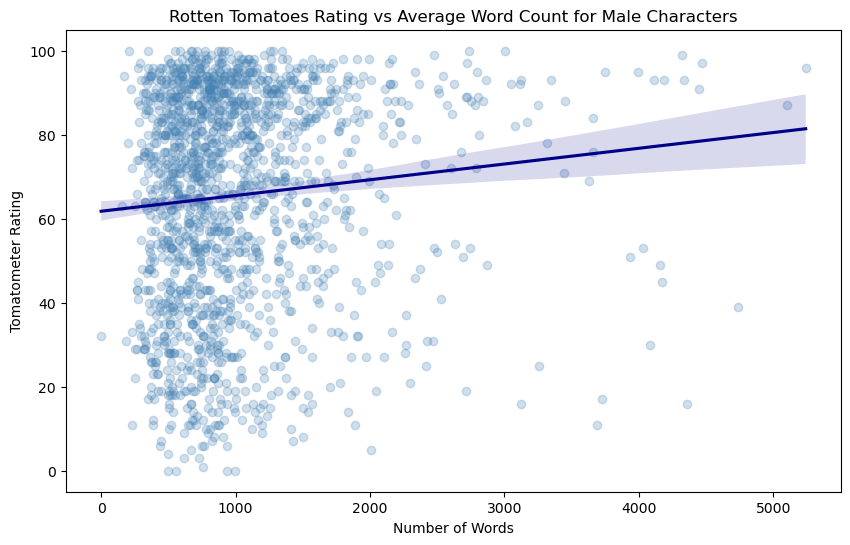

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=gender_rt,
    x="avg_male_words",
    y="tomatometer_rating",
    scatter_kws={"alpha": 0.25, "color": "steelblue"},
    line_kws={"color": "darkblue"}
)

plt.title("Rotten Tomatoes Rating vs Average Word Count for Male Characters")
plt.xlabel("Number of Words")
plt.ylabel("Tomatometer Rating")
plt.show()

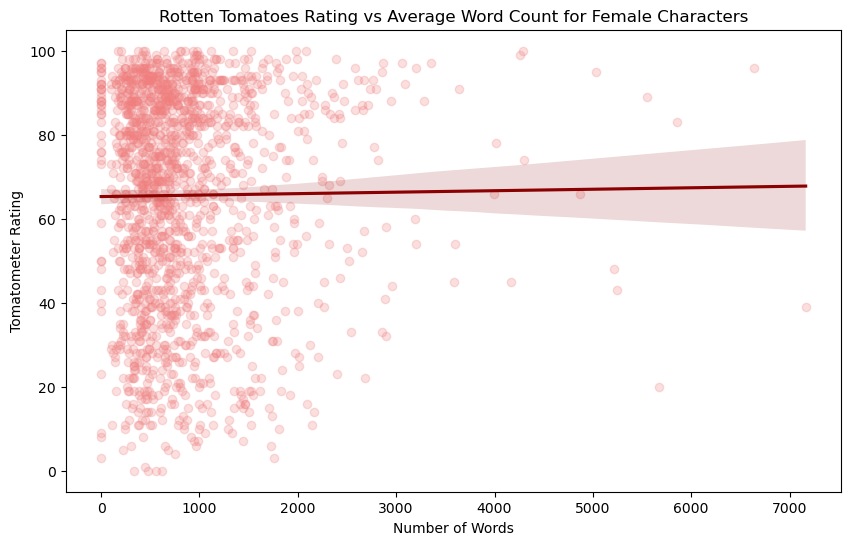

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(
    data=gender_rt,
    x="avg_female_words",
    y="tomatometer_rating",
    scatter_kws={"alpha": 0.25, "color": "lightcoral"},
    line_kws={"color": "darkred"}
)

plt.title("Rotten Tomatoes Rating vs Average Word Count for Female Characters")
plt.xlabel("Number of Words")
plt.ylabel("Tomatometer Rating")
plt.show()

                            OLS Regression Results                            
Dep. Variable:     tomatometer_rating   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Sun, 19 Oct 2025   Prob (F-statistic):                nan
Time:                        18:51:59   Log-Likelihood:                    nan
No. Observations:                1619   AIC:                               nan
Df Residuals:                    1616   BIC:                               nan
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                   nan        nan  

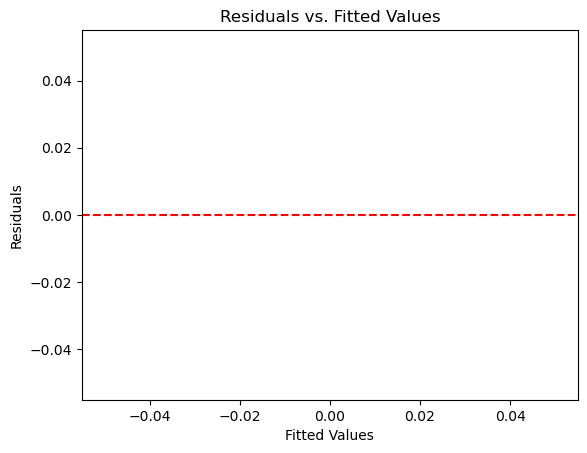

In [ ]:
# "total_words_f", "total_words_m"
# "num_characters_f", "num_characters_m"
# "avg_male_words", "avg_female_words"
X = sm.add_constant(gender_rt[["avg_male_words", "avg_female_words"]])  # independent variable
y = gender_rt['tomatometer_rating']  # dependent variable

model = sm.OLS(y, X).fit()
print(model.summary())

residuals = model.resid

plt.scatter(model.fittedvalues, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values')
plt.show()

In [ ]:
m_ols1 = smf.ols("total_nominations ~ pct_words_m + pct_chars_m + avg_male_words", data=oscars_summary).fit()
print(m_ols1.summary())

                            OLS Regression Results                            
Dep. Variable:      total_nominations   R-squared:                       0.024
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     15.89
Date:                Mon, 17 Nov 2025   Prob (F-statistic):           3.28e-10
Time:                        16:48:10   Log-Likelihood:                -4008.4
No. Observations:                1947   AIC:                             8025.
Df Residuals:                    1943   BIC:                             8047.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.4868      0.214     -2.

# Negative Binomial Regression Analysis